<a href="https://colab.research.google.com/github/Shivjeet-Rai/CEI-Celebal-Excellence-Intern-assignments/blob/main/tesla_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla Deliveries — End-to-End ML Pipeline

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import adfuller

print('All libraries imported ✓')

All libraries imported ✓


## 1. Load & Explore Data (EDA)

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print('Shape:', df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
print(df.isnull().sum())
print()
print('--- Basic Statistics ---')
df.describe()

--- Data Types ---
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

--- Missing Values ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

--- Basic Statistics ---


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
# Unique categories
print('Models  :', df['Model'].unique())
print('Regions :', df['Region'].unique())
print('Years   :', sorted(df['Year'].unique()))

Models  : ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Regions : ['Europe' 'Asia' 'North America' 'Middle East']
Years   : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


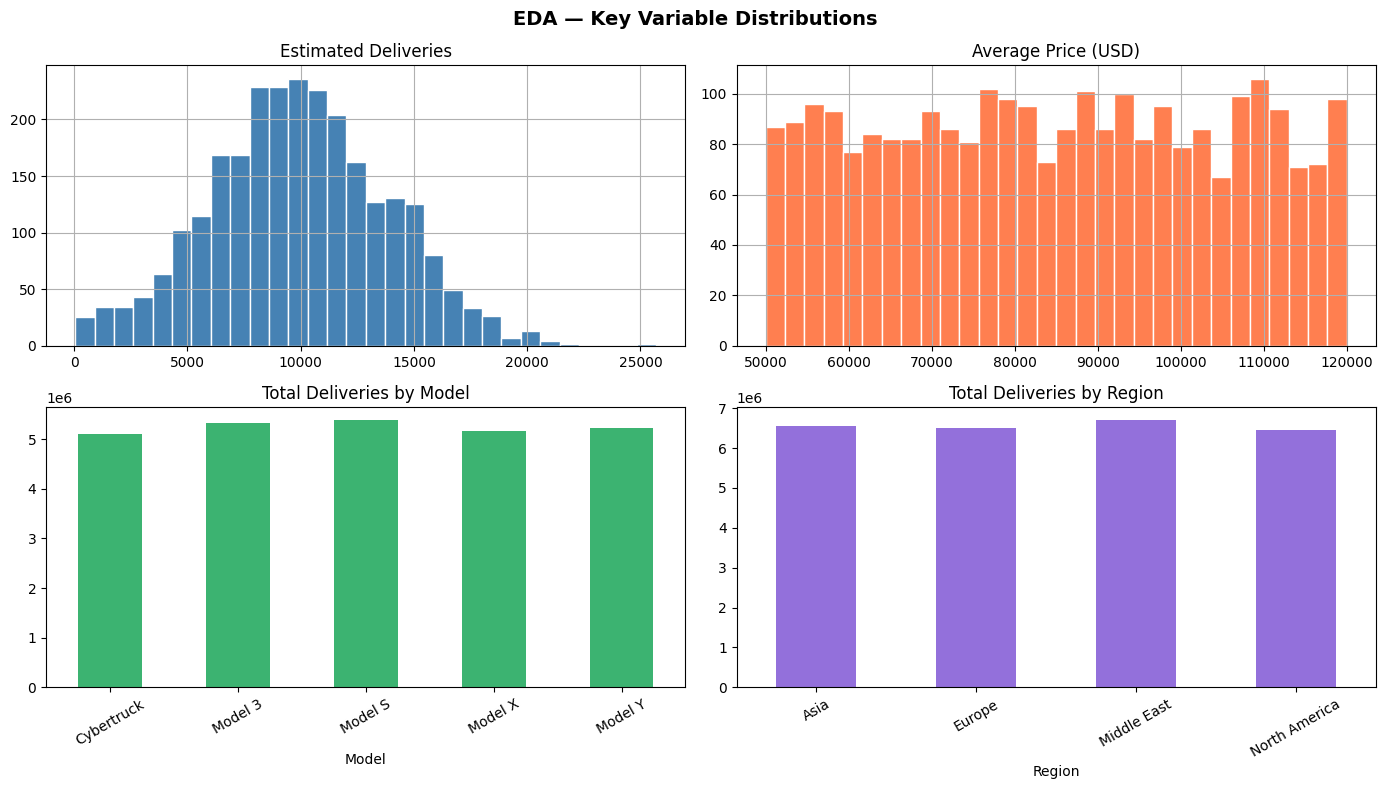

In [5]:
# EDA — distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('EDA — Key Variable Distributions', fontsize=14, fontweight='bold')

df['Estimated_Deliveries'].hist(ax=axes[0,0], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Estimated Deliveries')

df['Avg_Price_USD'].hist(ax=axes[0,1], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Average Price (USD)')

df.groupby('Model')['Estimated_Deliveries'].sum().plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Total Deliveries by Model')
axes[1,0].tick_params(axis='x', rotation=30)

df.groupby('Region')['Estimated_Deliveries'].sum().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Total Deliveries by Region')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

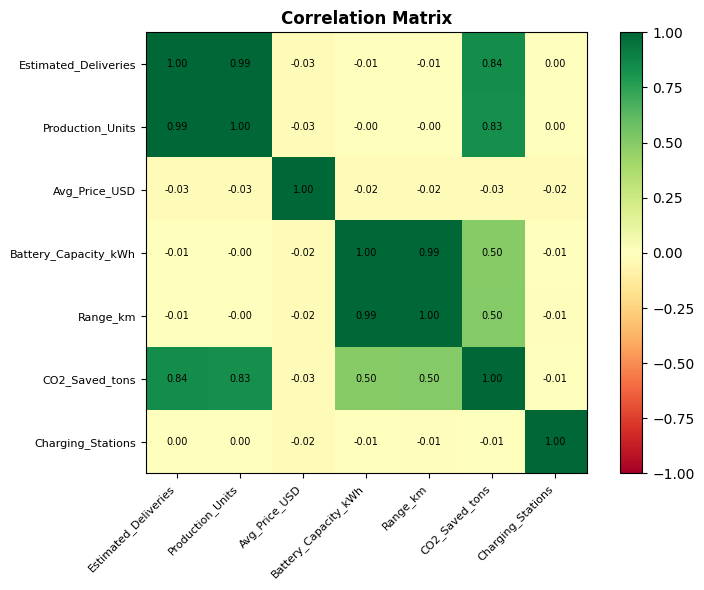

In [6]:
# EDA — Correlation heatmap
import matplotlib.cm as cm

numeric_cols = ['Estimated_Deliveries','Production_Units','Avg_Price_USD',
                'Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(numeric_cols, fontsize=8)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Time Series Components

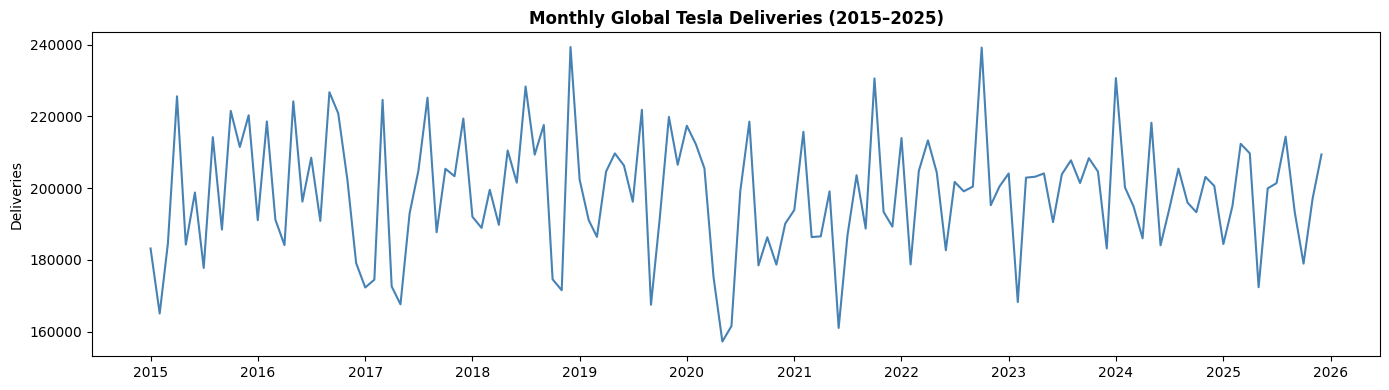

In [7]:
# Aggregate monthly global deliveries for time series analysis
ts = df.groupby(['Year','Month'])['Estimated_Deliveries'].sum().reset_index()
ts['Date'] = pd.to_datetime(ts[['Year','Month']].assign(day=1))
ts = ts.sort_values('Date').reset_index(drop=True)
ts.set_index('Date', inplace=True)

# Plot trend
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts['Estimated_Deliveries'], color='steelblue', linewidth=1.5)
ax.set_title('Monthly Global Tesla Deliveries (2015–2025)', fontweight='bold')
ax.set_ylabel('Deliveries')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

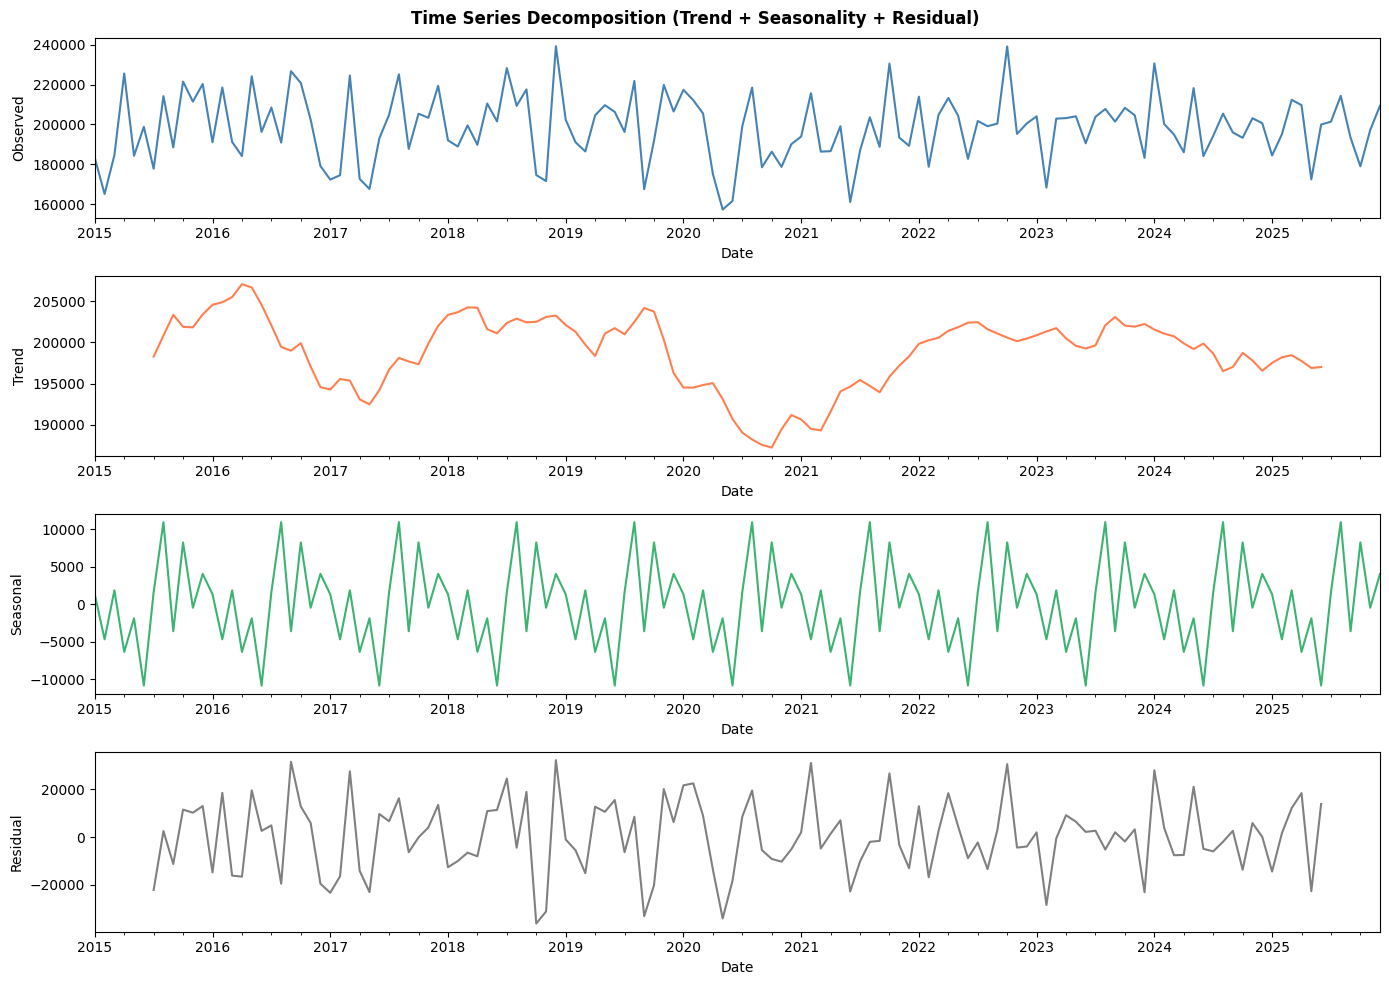

In [8]:
# Decompose: Trend + Seasonality + Residual
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts['Estimated_Deliveries'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
fig.suptitle('Time Series Decomposition (Trend + Seasonality + Residual)', fontweight='bold')

decomp.observed.plot(ax=axes[0], color='steelblue');   axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1], color='coral');          axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2], color='mediumseagreen'); axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3], color='gray');           axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

## 3. Stationarity Test (ADF)

In [9]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test — {name}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
    if result[1] < 0.05:
        print('  ✅ STATIONARY (reject H0)')
    else:
        print('  ❌ NON-STATIONARY (fail to reject H0)')
    print()

adf_test(ts['Estimated_Deliveries'], 'Raw Deliveries')

# If non-stationary → apply differencing
ts['Deliveries_diff'] = ts['Estimated_Deliveries'].diff()
adf_test(ts['Deliveries_diff'], 'First-Differenced Deliveries')

ADF Test — Raw Deliveries
  ADF Statistic : -8.8810
  p-value       : 0.0000
  Critical (5%) : -2.8840
  ✅ STATIONARY (reject H0)

ADF Test — First-Differenced Deliveries
  ADF Statistic : -7.0101
  p-value       : 0.0000
  Critical (5%) : -2.8853
  ✅ STATIONARY (reject H0)



## 4. Feature Engineering (Lag Features + Rolling Statistics)

In [10]:
# Work on the time-series dataframe
feat = ts[['Estimated_Deliveries']].copy()

# --- Lag Features ---
for lag in [1, 2, 3, 6, 12]:
    feat[f'lag_{lag}'] = feat['Estimated_Deliveries'].shift(lag)

# --- Rolling Statistics ---
feat['rolling_mean_3']  = feat['Estimated_Deliveries'].shift(1).rolling(3).mean()
feat['rolling_mean_6']  = feat['Estimated_Deliveries'].shift(1).rolling(6).mean()
feat['rolling_std_3']   = feat['Estimated_Deliveries'].shift(1).rolling(3).std()
feat['rolling_min_6']   = feat['Estimated_Deliveries'].shift(1).rolling(6).min()
feat['rolling_max_6']   = feat['Estimated_Deliveries'].shift(1).rolling(6).max()

# --- Calendar Features ---
feat['month']    = feat.index.month
feat['quarter']  = feat.index.quarter
feat['year']     = feat.index.year
feat['is_q4']    = (feat.index.quarter == 4).astype(int)   # Tesla historically peaks in Q4

# Drop rows with NaN (introduced by lags/rolling)
feat.dropna(inplace=True)

print('Feature matrix shape:', feat.shape)
feat.head()

Feature matrix shape: (120, 15)


,Estimated_Deliveries,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,rolling_min_6,rolling_max_6,month,quarter,year,is_q4
Date,,,,,,,,,,,,,,,
2016-01-01,191069,220332.0,211490.0,221541.0,177759.0,183180.0,217787.666667,205632.166667,5487.337636,177759.0,221541.0,1,1,2016,0
2016-02-01,218600,191069.0,220332.0,211490.0,214223.0,165053.0,207630.333333,207850.500000,15008.449698,188448.0,221541.0,2,1,2016,0
2016-03-01,191208,218600.0,191069.0,220332.0,188448.0,184567.0,210000.333333,208580.000000,16417.871127,188448.0,221541.0,3,1,2016,0
2016-04-01,184134,191208.0,218600.0,191069.0,221541.0,225623.0,200292.333333,209040.000000,15855.056743,191069.0,221541.0,4,2,2016,0
2016-05-01,224220,184134.0,191208.0,218600.0,211490.0,184264.0,197980.666667,202805.500000,18203.792169,184134.0,220332.0,5,2,2016,0


## 5. Data Leakage Prevention — Chronological Split

In [11]:
# ⚠️  DATA LEAKAGE RULE: NEVER use random_state splits on time series data!
# Always split chronologically so future data never leaks into training.

TARGET = 'Estimated_Deliveries'
FEATURES = [c for c in feat.columns if c != TARGET]

X = feat[FEATURES]
y = feat[TARGET]

split_idx = int(len(feat) * 0.80)   # 80% train, 20% test
split_date = feat.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train : {X_train.index[0].date()} → {X_train.index[-1].date()}  ({len(X_train)} rows)')
print(f'Test  : {X_test.index[0].date()}  → {X_test.index[-1].date()}   ({len(X_test)} rows)')
print()
print('✅ No data leakage: test set is entirely AFTER training set')

Train : 2016-01-01 → 2023-12-01  (96 rows)
Test  : 2024-01-01  → 2025-12-01   (24 rows)

✅ No data leakage: test set is entirely AFTER training set


## 6. ML Pipelines — Linear, Ridge & Lasso Regression

In [12]:
# Build sklearn Pipelines (scaler + model) to avoid leakage
# Scaler is fit ONLY on training data inside the pipeline

pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Ridge (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ]),
    'Lasso (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Lasso(alpha=1.0, max_iter=10000))
    ])
}

print('Pipelines built ✓')
print(pipelines['Ridge (L2)'])

Pipelines built ✓
Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])


## 7. Cross Validation (TimeSeriesSplit)

In [13]:
# TimeSeriesSplit = chronological CV — never shuffles data!
tscv = TimeSeriesSplit(n_splits=5)

print('Cross-Validation Results (5-fold TimeSeriesSplit)\n' + '='*50)
cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=tscv, scoring='r2')
    cv_results[name] = scores
    print(f'{name:<25} R² per fold: {[round(s,3) for s in scores]}')
    print(f'{"":25} Mean R²: {scores.mean():.4f}  ±  {scores.std():.4f}\n')

Cross-Validation Results (5-fold TimeSeriesSplit)
Linear Regression         R² per fold: [np.float64(-30.818), np.float64(-1.354), np.float64(-0.812), np.float64(-0.752), np.float64(-0.378)]
                          Mean R²: -6.8231  ±  12.0017

Ridge (L2)                R² per fold: [np.float64(-8.297), np.float64(-1.397), np.float64(-0.723), np.float64(-0.677), np.float64(-0.38)]
                          Mean R²: -2.2948  ±  3.0194

Lasso (L1)                R² per fold: [np.float64(-30.752), np.float64(-1.355), np.float64(-0.812), np.float64(-0.751), np.float64(-0.378)]
                          Mean R²: -6.8094  ±  11.9753



## 8. Hyperparameter Tuning (GridSearchCV)

In [14]:
# Tune Ridge and Lasso alpha using GridSearchCV + TimeSeriesSplit
param_grid = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

best_models = {}

for name in ['Ridge (L2)', 'Lasso (L1)']:
    gs = GridSearchCV(pipelines[name], param_grid,
                      cv=tscv, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f'{name}: best alpha = {gs.best_params_["model__alpha"]}  '
          f'| CV R² = {gs.best_score_:.4f}')

# Also fit plain Linear Regression (no alpha)
pipelines['Linear Regression'].fit(X_train, y_train)
best_models['Linear Regression'] = pipelines['Linear Regression']
print('Linear Regression: no hyperparameter to tune')

Ridge (L2): best alpha = 1000  | CV R² = -0.0695
Lasso (L1): best alpha = 1000  | CV R² = -1.9138
Linear Regression: no hyperparameter to tune


## 9. Evaluation Metrics on Test Set

In [15]:
def evaluate(model, X, y, name='Model'):
    pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mae  = mean_absolute_error(y, pred)
    r2   = r2_score(y, pred)
    print(f'{name:<25}  RMSE: {rmse:>10,.1f}  |  MAE: {mae:>10,.1f}  |  R²: {r2:.4f}')
    return pred

print('Evaluation on HELD-OUT TEST SET\n' + '='*65)
predictions = {}
for name, model in best_models.items():
    predictions[name] = evaluate(model, X_test, y_test, name)

Evaluation on HELD-OUT TEST SET
Ridge (L2)                 RMSE:   12,824.0  |  MAE:    9,757.5  |  R²: -0.0047
Lasso (L1)                 RMSE:   13,019.4  |  MAE:    9,896.7  |  R²: -0.0355
Linear Regression          RMSE:   14,243.0  |  MAE:   11,158.2  |  R²: -0.2393


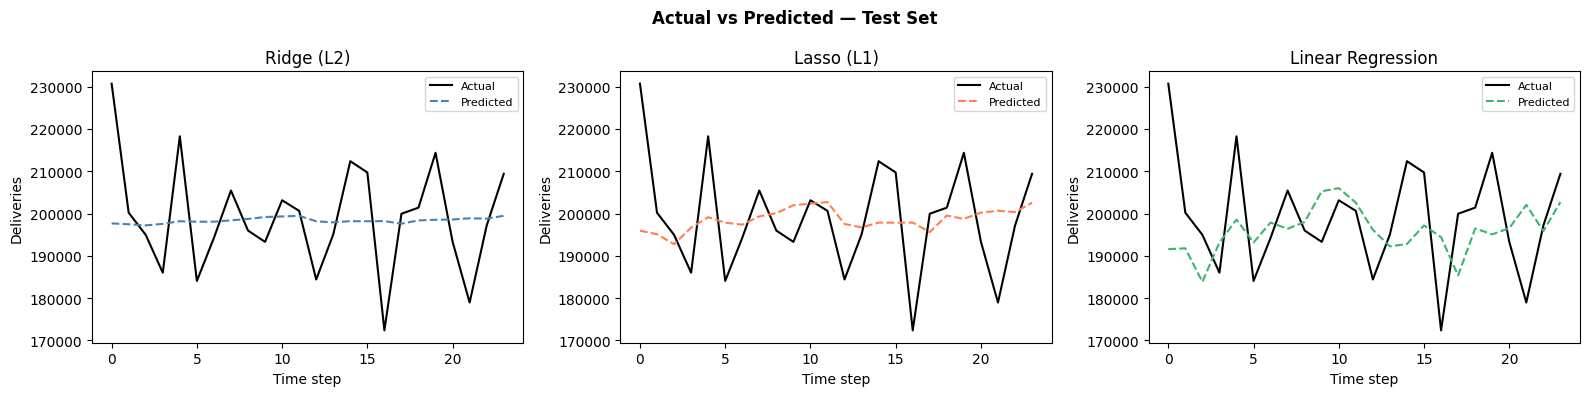

In [16]:
# Plot actual vs predicted
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Actual vs Predicted — Test Set', fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen']
for ax, (name, pred), color in zip(axes, predictions.items(), colors):
    ax.plot(y_test.values, label='Actual', color='black', linewidth=1.5)
    ax.plot(pred, label='Predicted', color=color, linewidth=1.5, linestyle='--')
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Deliveries')

plt.tight_layout()
plt.show()

## 10. Forecasting — Future 6 Months

In [17]:
# Pick best model (highest R² on test)
best_name = max(predictions, key=lambda n: r2_score(y_test, predictions[n]))
best_model = best_models[best_name]
print(f'Best model selected: {best_name}')

# Iterative forecast: use each prediction as the next lag
history = feat['Estimated_Deliveries'].tolist()
forecast_dates = pd.date_range(feat.index[-1] + pd.DateOffset(months=1), periods=6, freq='MS')
forecasts = []

for fdate in forecast_dates:
    lag_vals = history[-12:]    # last 12 values
    row = {
        'lag_1': lag_vals[-1],
        'lag_2': lag_vals[-2],
        'lag_3': lag_vals[-3],
        'lag_6': lag_vals[-6],
        'lag_12': lag_vals[-12],
        'rolling_mean_3': np.mean(lag_vals[-3:]),
        'rolling_mean_6': np.mean(lag_vals[-6:]),
        'rolling_std_3':  np.std(lag_vals[-3:]),
        'rolling_min_6':  np.min(lag_vals[-6:]),
        'rolling_max_6':  np.max(lag_vals[-6:]),
        'month':   fdate.month,
        'quarter': fdate.quarter,
        'year':    fdate.year,
        'is_q4':   int(fdate.quarter == 4)
    }
    X_fut = pd.DataFrame([row])[FEATURES]
    pred_val = best_model.predict(X_fut)[0]
    forecasts.append(pred_val)
    history.append(pred_val)

forecast_series = pd.Series(forecasts, index=forecast_dates)
print('\n6-Month Forecast:')
for d, v in forecast_series.items():
    print(f'  {d.strftime("%b %Y")}: {v:,.0f} deliveries')

Best model selected: Ridge (L2)

6-Month Forecast:
  Jan 2026: 197,845 deliveries
  Feb 2026: 197,869 deliveries
  Mar 2026: 198,012 deliveries
  Apr 2026: 198,406 deliveries
  May 2026: 198,430 deliveries
  Jun 2026: 198,607 deliveries


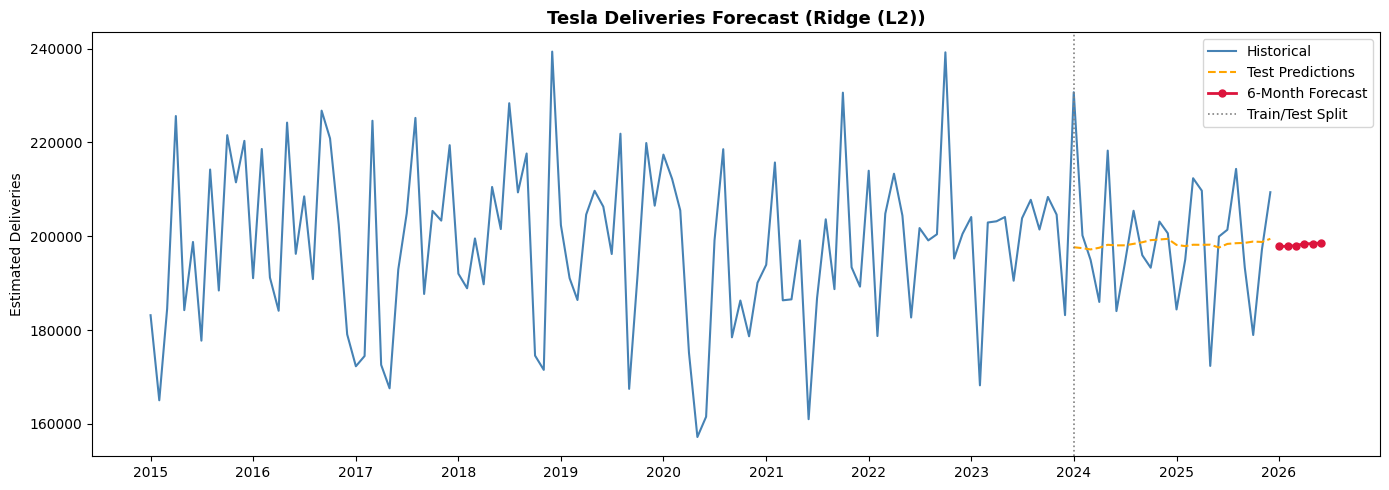


✅ End-to-end ML Pipeline Complete!


In [18]:
# Final forecast plot
fig, ax = plt.subplots(figsize=(14, 5))

# Historical
ax.plot(ts.index, ts['Estimated_Deliveries'], label='Historical', color='steelblue', linewidth=1.5)

# Test predictions
ax.plot(X_test.index, predictions[best_name], label='Test Predictions', color='orange', linewidth=1.5, linestyle='--')

# Future forecast
ax.plot(forecast_series.index, forecast_series.values, label='6-Month Forecast',
        color='crimson', linewidth=2, marker='o', markersize=5)

# Vertical line at train/test split
ax.axvline(x=split_date, color='gray', linestyle=':', linewidth=1.2, label='Train/Test Split')

ax.set_title(f'Tesla Deliveries Forecast ({best_name})', fontweight='bold', fontsize=13)
ax.set_ylabel('Estimated Deliveries')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()
print('\n✅ End-to-end ML Pipeline Complete!')